In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/transactions.csv')

# Show first 5 rows
df.head()

,transaction_id,date,amount,category,merchant,payment_method,transaction_type,city,hour,day_type
0,TXN001,2026-01-01,250,Food,Zomato,GPay,Debit,Delhi,21,Weekday
1,TXN002,2026-01-01,1200,Shopping,Amazon,PhonePe,Debit,Delhi,14,Weekday
2,TXN003,2026-01-02,80,Transport,Metro Card,GPay,Debit,Delhi,9,Weekday
3,TXN004,2026-01-02,499,Entertainment,Netflix,UPI,Debit,Delhi,22,Weekday
4,TXN005,2026-01-03,350,Food,Swiggy,Paytm,Debit,Delhi,23,Weekend


In [ ]:
df.shape


(20, 10)

In [ ]:
df.columns

Index(['transaction_id', 'date', 'amount', 'category', 'merchant',
       'payment_method', 'transaction_type', 'city', 'hour', 'day_type'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    20 non-null     object
 1   date              20 non-null     object
 2   amount            20 non-null     int64 
 3   category          20 non-null     object
 4   merchant          20 non-null     object
 5   payment_method    20 non-null     object
 6   transaction_type  20 non-null     object
 7   city              20 non-null     object
 8   hour              20 non-null     int64 
 9   day_type          20 non-null     object
dtypes: int64(2), object(8)
memory usage: 1.7+ KB


In [ ]:
df.describe()

,amount,hour
count,20.000000,20.000000
mean,704.400000,16.700000
std,742.758543,5.694873
min,60.000000,8.000000
25%,186.750000,10.750000
50%,375.000000,18.500000
75%,937.500000,22.000000
max,2500.000000,23.000000


In [ ]:
df.isnull().sum()

,0
transaction_id,0
date,0
amount,0
category,0
merchant,0
payment_method,0
transaction_type,0
city,0
hour,0
day_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['category'].value_counts()

,count
category,
Food,7
Shopping,4
Transport,4
Entertainment,3
Bills,2


In [ ]:
 df['amount'].mean()

np.float64(704.4)

In [ ]:
df['amount'].max()

2500

In [ ]:
df['amount'].min()

60

In [ ]:
df['amount'].sum()

np.int64(14088)

In [ ]:
df.groupby('category')['amount'].sum()

,amount
category,
Bills,4000
Entertainment,848
Food,3010
Shopping,5900
Transport,330


In [ ]:
df['payment_method'].value_counts()

,count
payment_method,
GPay,11
UPI,4
PhonePe,3
Paytm,2


In [ ]:
df.groupby('day_type')['amount'].sum()

,amount
day_type,
Weekday,9028
Weekend,5060


In [ ]:
late_night = df[df['hour'] >= 22]
late_night

,transaction_id,date,amount,category,merchant,payment_method,transaction_type,city,hour,day_type
3,TXN004,2026-01-02,499,Entertainment,Netflix,UPI,Debit,Delhi,22,Weekday
4,TXN005,2026-01-03,350,Food,Swiggy,Paytm,Debit,Delhi,23,Weekend
9,TXN010,2026-01-05,400,Food,Dominos,PhonePe,Debit,Delhi,22,Weekday
10,TXN011,2026-01-06,550,Food,Zomato,GPay,Debit,Delhi,23,Weekday
16,TXN017,2026-01-09,290,Food,McDonalds,PhonePe,Debit,Delhi,22,Weekday
19,TXN020,2026-01-10,850,Food,Swiggy,GPay,Debit,Delhi,23,Weekend


In [ ]:
late_night['amount'].sum()

np.int64(2939)

In [ ]:
clean_df = df.copy()

In [ ]:
clean_df.isnull().sum()

,0
transaction_id,0
date,0
amount,0
category,0
merchant,0
payment_method,0
transaction_type,0
city,0
hour,0
day_type,0


In [ ]:
clean_df.duplicated().sum()

np.int64(0)

In [ ]:
clean_df.dtypes

,0
transaction_id,object
date,object
amount,int64
category,object
merchant,object
payment_method,object
transaction_type,object
city,object
hour,int64
day_type,object


In [ ]:
clean_df['date'] = pd.to_datetime(clean_df['date'])

In [ ]:
clean_df.dtypes

,0
transaction_id,object
date,datetime64[ns]
amount,int64
category,object
merchant,object
payment_method,object
transaction_type,object
city,object
hour,int64
day_type,object


In [ ]:
clean_df['month'] = clean_df['date'].dt.month

In [ ]:
clean_df['day_name'] = clean_df['date'].dt.day_name()

In [ ]:
clean_df['is_weekend'] = clean_df['day_name'].isin(['Saturday', 'Sunday'])

In [ ]:
def spending_time(hour):
    if hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    elif hour < 21:
        return 'Evening'
    else:
        return 'Night'

clean_df['time_period'] = clean_df['hour'].apply(spending_time)

In [ ]:
clean_df.head()

,transaction_id,date,amount,category,merchant,payment_method,transaction_type,city,hour,day_type,month,day_name,is_weekend,time_period
0,TXN001,2026-01-01,250,Food,Zomato,GPay,Debit,Delhi,21,Weekday,1,Thursday,False,Night
1,TXN002,2026-01-01,1200,Shopping,Amazon,PhonePe,Debit,Delhi,14,Weekday,1,Thursday,False,Afternoon
2,TXN003,2026-01-02,80,Transport,Metro Card,GPay,Debit,Delhi,9,Weekday,1,Friday,False,Morning
3,TXN004,2026-01-02,499,Entertainment,Netflix,UPI,Debit,Delhi,22,Weekday,1,Friday,False,Night
4,TXN005,2026-01-03,350,Food,Swiggy,Paytm,Debit,Delhi,23,Weekend,1,Saturday,True,Night


In [ ]:
clean_df.to_csv('clean_transactions.csv', index=False)

In [ ]:
clean_df.groupby('time_period')['amount'].sum()

,amount
time_period,
Afternoon,4400
Evening,1849
Morning,4330
Night,3509


In [ ]:
clean_df.groupby('day_name')['amount'].sum()

,amount
day_name,
Friday,1569
Monday,599
Saturday,2800
Sunday,2260
Thursday,3400
Tuesday,3050
Wednesday,410


In [ ]:
clean_df.groupby('merchant')['amount'].sum().sort_values(ascending=False)

,amount
merchant,
Ajio,2500
Electricity,2200
Internet,1800
Swiggy,1520
Myntra,1500
Amazon,1200
Zomato,800
Nykaa,700
Netflix,499


In [ ]:
clean_df.groupby('is_weekend')['amount'].mean()

,amount
is_weekend,
False,644.857143
True,843.333333


In [ ]:
clean_df[clean_df['amount'] > 1000]

,transaction_id,date,amount,category,merchant,payment_method,transaction_type,city,hour,day_type,month,day_name,is_weekend,time_period
1,TXN002,2026-01-01,1200,Shopping,Amazon,PhonePe,Debit,Delhi,14,Weekday,1,Thursday,False,Afternoon
5,TXN006,2026-01-03,1500,Shopping,Myntra,GPay,Debit,Delhi,18,Weekend,1,Saturday,True,Evening
7,TXN008,2026-01-04,2200,Bills,Electricity,UPI,Debit,Delhi,10,Weekend,1,Sunday,True,Morning
11,TXN012,2026-01-06,2500,Shopping,Ajio,Paytm,Debit,Delhi,16,Weekday,1,Tuesday,False,Afternoon
14,TXN015,2026-01-08,1800,Bills,Internet,GPay,Debit,Delhi,11,Weekday,1,Thursday,False,Morning


In [ ]:
clean_df['high_spend'] = clean_df['amount'] > 1000

In [ ]:
clean_df['high_spend'].value_counts()

,count
high_spend,
False,15
True,5


In [ ]:
clean_df.to_csv('finance_cleaned_v1.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
category_spending = clean_df.groupby('category')['amount'].sum().reset_index()

fig = px.bar(
    category_spending,
    x='category',
    y='amount',
    title='Total Spending by Category'
)

fig.show()

In [ ]:
payment_counts = clean_df['payment_method'].value_counts().reset_index()

fig = px.pie(
    payment_counts,
    names='payment_method',
    values='count',
    title='Payment Method Distribution'
)

fig.show()

In [ ]:
merchant_spending = clean_df.groupby('merchant')['amount'].sum().reset_index()

fig = px.bar(
    merchant_spending,
    x='merchant',
    y='amount',
    title='Merchant-wise Spending'
)

fig.show()

In [ ]:
time_spending = clean_df.groupby('time_period')['amount'].sum().reset_index()

fig = px.bar(
    time_spending,
    x='time_period',
    y='amount',
    title='Spending by Time of Day'
)

fig.show()

In [ ]:
weekend_spending = clean_df.groupby('day_type')['amount'].sum().reset_index()

fig = px.bar(
    weekend_spending,
    x='day_type',
    y='amount',
    title='Weekend vs Weekday Spending'
)

fig.show()

In [ ]:
daily_spending = clean_df.groupby('date')['amount'].sum().reset_index()

fig = px.line(
    daily_spending,
    x='date',
    y='amount',
    title='Daily Spending Trend',
    markers=True
)

fig.show()

In [ ]:
high_spending = clean_df[clean_df['amount'] > 1000]

fig = px.bar(
    high_spending,
    x='merchant',
    y='amount',
    title='High Spending Transactions'
)

fig.show()

In [ ]:
!pip install seaborn

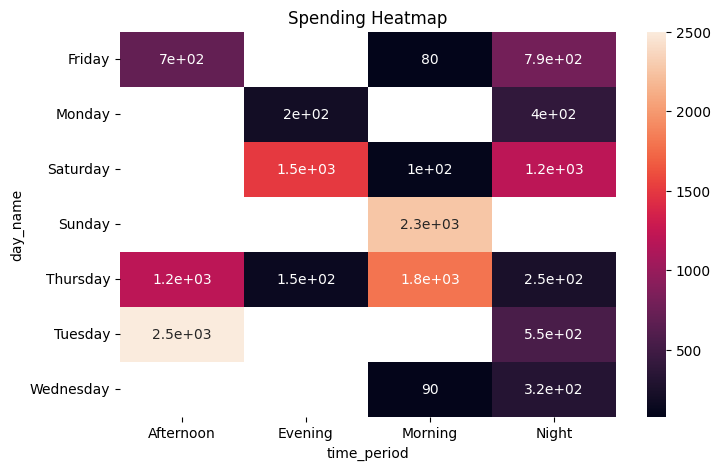

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_table = clean_df.pivot_table(
    values='amount',
    index='day_name',
    columns='time_period',
    aggfunc='sum'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True)

plt.title('Spending Heatmap')
plt.show()

In [ ]:
clean_df['impulsive_spend'] = (
    (clean_df['hour'] >= 22) |
    (clean_df['amount'] > 700)
)

clean_df[['merchant', 'amount', 'hour', 'impulsive_spend']].head()

,merchant,amount,hour,impulsive_spend
0,Zomato,250,21,False
1,Amazon,1200,14,True
2,Metro Card,80,9,False
3,Netflix,499,22,True
4,Swiggy,350,23,True


In [ ]:
clean_df['impulsive_spend'].value_counts()

,count
impulsive_spend,
True,11
False,9


In [ ]:
clean_df[clean_df['impulsive_spend'] == True]['amount'].sum()

np.int64(12139)

In [ ]:
impulsive_counts = clean_df['impulsive_spend'].value_counts().reset_index()

fig = px.pie(
    impulsive_counts,
    names='impulsive_spend',
    values='count',
    title='Impulsive Spending Distribution'
)

fig.show()

In [ ]:
avg_spending = clean_df['amount'].mean()

high_spending_count = (
    clean_df['amount'] > 1000
).sum()

impulsive_count = (
    clean_df['impulsive_spend']
).sum()

print(avg_spending)
print(high_spending_count)
print(impulsive_count)

704.4
5
11


In [ ]:
if (
    avg_spending > 800
    or high_spending_count > 5
    or impulsive_count > 5
):
    risk = "HIGH"

elif (
    avg_spending > 400
):
    risk = "MEDIUM"

else:
    risk = "LOW"

print("Overspending Risk:", risk)

Overspending Risk: HIGH


In [ ]:
score = 100

score -= impulsive_count * 5
score -= high_spending_count * 5

score = max(score, 0)

print("Financial Health Score:", score)

Financial Health Score: 20


In [ ]:
if score >= 80:
    status = "Excellent"

elif score >= 60:
    status = "Moderate"

else:
    status = "Poor"

print(status)

Poor


In [ ]:
recommendations = []

if impulsive_count > 5:
    recommendations.append(
        "Reduce late-night spending."
    )

if high_spending_count > 3:
    recommendations.append(
        "Avoid frequent high-value purchases."
    )

if avg_spending > 700:
    recommendations.append(
        "Set a monthly spending budget."
    )

for rec in recommendations:
    print("-", rec)

- Reduce late-night spending.
- Avoid frequent high-value purchases.
- Set a monthly spending budget.


In [ ]:
clean_df.to_csv(
    'finance_project_final.csv',
    index=False
)

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
ml_df = clean_df.copy()

ml_df['category'] = ml_df['category'].astype('category').cat.codes
ml_df['payment_method'] = ml_df['payment_method'].astype('category').cat.codes
ml_df['day_type'] = ml_df['day_type'].astype('category').cat.codes
ml_df['time_period'] = ml_df['time_period'].astype('category').cat.codes

In [ ]:
X = ml_df[
    [
        'category',
        'payment_method',
        'hour',
        'day_type',
        'time_period'
    ]
]

y = ml_df['amount']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

predictions

array([ 190.99226954, 1579.42773425, 1687.9753057 , 1678.25356259])

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison

,Actual,Predicted
0,250,190.992270
17,700,1579.427734
15,150,1687.975306
1,1200,1678.253563


In [ ]:
error = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", error)

Mean Absolute Error: 738.6660832499504


In [ ]:
new_transaction = [[
    0,  # category
    1,  # payment method
    22, # hour
    1,  # weekday/weekend
    3   # time period
]]

prediction = model.predict(
    new_transaction
)

print(
    "Predicted Spend Amount:",
    prediction[0]
)

Predicted Spend Amount: 1211.1203064968872


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [ ]:
ml_df['overspend'] = (
    ml_df['amount'] > 1000
).astype(int)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
X = ml_df[
    [
        'category',
        'payment_method',
        'hour',
        'day_type'
    ]
]

y = ml_df['overspend']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
tree_model = DecisionTreeClassifier()

tree_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier()

In [ ]:
predictions = tree_model.predict(
    X_test
)

predictions

array([0, 1, 1, 1])

In [ ]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.5


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 71.5 MB/s eta 0:00:00


In [4]:
!pip install streamlit-option-menu streamlit-extras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 32.8 MB/s eta 0:00:00


In [5]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np
from streamlit_option_menu import option_menu

# ====================================
# PAGE CONFIG
# ====================================

st.set_page_config(
    page_title="Finance Intelligence",
    page_icon="💰",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ====================================
# PREMIUM CSS
# ====================================

st.markdown("""
<style>

/* Main background */
.stApp {
    background-color: #F6F8FC;
}

/* Remove default padding */
.block-container {
    padding-top: 2rem;
    padding-bottom: 2rem;
    padding-left: 3rem;
    padding-right: 3rem;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background: white;
    border-right: 1px solid #EAEAEA;
}

/* Title */
.main-title {
    font-size: 42px;
    font-weight: 700;
    color: #111827;
}

.subtitle {
    color: #6B7280;
    font-size: 16px;
    margin-bottom: 30px;
}

/* KPI Cards */
.metric-card {
    background: white;
    border-radius: 24px;
    padding: 25px;
    box-shadow: 0px 8px 25px rgba(0,0,0,0.06);
    border: 1px solid #F1F1F1;
}

/* Insight cards */
.insight-card {
    background: white;
    padding: 22px;
    border-radius: 22px;
    box-shadow: 0px 4px 15px rgba(0,0,0,0.05);
    margin-bottom: 15px;
}

/* Chart containers */
.chart-card {
    background: white;
    border-radius: 24px;
    padding: 20px;
    box-shadow: 0px 4px 18px rgba(0,0,0,0.05);
}

/* Recommendation box */
.recommend-box {
    background: linear-gradient(
        135deg,
        #EEF4FF,
        #FFFFFF
    );

    padding: 18px;
    border-radius: 18px;
    margin-bottom: 12px;
    border-left: 5px solid #2563EB;
}

</style>
""", unsafe_allow_html=True)

# ====================================
# HEADER
# ====================================

st.markdown(
    """
    <div class='main-title'>
    💰 Personal Finance Intelligence
    </div>

    <div class='subtitle'>
    AI-powered spending intelligence dashboard
    </div>
    """,
    unsafe_allow_html=True
)

# ====================================
# SIDEBAR
# ====================================

with st.sidebar:

    st.markdown("## Navigation")

    selected = option_menu(
        menu_title=None,
        options=[
            "Overview",
            "Analytics",
            "Behavior",
            "Recommendations"
        ],
        icons=[
            "house",
            "bar-chart",
            "activity",
            "lightbulb"
        ],
        default_index=0
    )

    st.markdown("---")

    uploaded_file = st.file_uploader(
        "Upload CSV",
        type=["csv"]
    )

# ====================================
# IF NO FILE
# ====================================

if uploaded_file is None:

    st.info(
        "Upload a financial transaction CSV file to begin."
    )

    st.stop()

# ====================================
# LOAD DATA
# ====================================

df = pd.read_csv(uploaded_file)

df.columns = (
    df.columns
    .str.lower()
    .str.strip()
)

df.drop_duplicates(inplace=True)

# Date cleaning
if 'date' in df.columns:
    df['date'] = pd.to_datetime(
        df['date'],
        errors='coerce'
    )

# ====================================
# FEATURES
# ====================================

if 'hour' in df.columns:

    def spending_time(hour):

        if hour < 12:
            return "Morning"

        elif hour < 17:
            return "Afternoon"

        elif hour < 21:
            return "Evening"

        return "Night"

    df['time_period'] = (
        df['hour']
        .apply(spending_time)
    )

# ====================================
# KPI VALUES
# ====================================

total_spending = (
    df['amount'].sum()
)

avg_spending = (
    df['amount'].mean()
)

highest_expense = (
    df['amount'].max()
)

transaction_count = len(df)

# ====================================
# PAGE 1 OVERVIEW
# ====================================

if selected == "Overview":

    st.subheader("Financial Overview")

    c1, c2, c3, c4 = st.columns(4)

    c1.metric(
        "💸 Total Spending",
        f"₹{round(total_spending)}"
    )

    c2.metric(
        "📈 Avg Spend",
        f"₹{round(avg_spending)}"
    )

    c3.metric(
        "🔥 Highest Expense",
        f"₹{round(highest_expense)}"
    )

    c4.metric(
        "🧾 Transactions",
        transaction_count
    )

    st.markdown("### Dataset Preview")

    st.dataframe(
        df.head(10),
        use_container_width=True
    )

# ====================================
# ANALYTICS PAGE
# ====================================

elif selected == "Analytics":

    st.subheader(
        "Spending Analytics"
    )

    col1, col2 = st.columns(2)

    if 'category' in df.columns:

        category_data = (
            df.groupby('category')
            ['amount']
            .sum()
            .reset_index()
        )

        fig1 = px.bar(
            category_data,
            x='category',
            y='amount',
            title="Category Spending"
        )

        col1.plotly_chart(
            fig1,
            use_container_width=True
        )

    if 'merchant' in df.columns:

        merchant_data = (
            df.groupby('merchant')
            ['amount']
            .sum()
            .reset_index()
            .sort_values(
                by='amount',
                ascending=False
            )
            .head(10)
        )

        fig2 = px.bar(
            merchant_data,
            x='merchant',
            y='amount',
            title="Top Merchants"
        )

        col2.plotly_chart(
            fig2,
            use_container_width=True
        )

    if 'date' in df.columns:

        daily = (
            df.groupby('date')
            ['amount']
            .sum()
            .reset_index()
        )

        fig3 = px.line(
            daily,
            x='date',
            y='amount',
            markers=True,
            title="Daily Spending Trend"
        )

        st.plotly_chart(
            fig3,
            use_container_width=True
        )

# ====================================
# BEHAVIOR PAGE
# ====================================

elif selected == "Behavior":

    st.subheader(
        "Behavioral Analytics"
    )

    if 'hour' in df.columns:

        df['impulsive'] = (
            (df['hour'] >= 22)
            |
            (df['amount'] > 700)
        )

        impulsive_count = (
            df['impulsive']
            .sum()
        )

        st.metric(
            "⚠️ Impulsive Purchases",
            impulsive_count
        )

        fig4 = px.pie(
            df,
            names='impulsive',
            title="Impulsive Spending"
        )

        st.plotly_chart(
            fig4,
            use_container_width=True
        )

# ====================================
# RECOMMENDATIONS
# ====================================

elif selected == "Recommendations":

    st.subheader(
        "Smart Recommendations"
    )

    recommendations = []

    if avg_spending > 700:

        recommendations.append(
            "💡 Your spending is relatively high. Consider setting a monthly spending cap."
        )

    if 'merchant' in df.columns:

        top_merchant = (
            df.groupby('merchant')
            ['amount']
            .sum()
            .idxmax()
        )

        recommendations.append(
            f"🛍️ Highest spending occurs at {top_merchant}. Consider monitoring expenses there."
        )

    if len(recommendations) == 0:

        st.success(
            "Healthy spending pattern detected."
        )

    else:

        for rec in recommendations:

            st.markdown(
                f"""
                <div class='recommend-box'>
                {rec}
                </div>
                """,
                unsafe_allow_html=True
            )

Overwriting app.py


In [2]:
!pip install streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.9 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-15 02:40:25.544 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.168.58.204:8501

